# Öneri Modeli — Adım Adım İnceleme

Bu notebook, `train.py`'deki aynı ALS + hibrit kategori skorlama mantığını **hücre hücre** çalıştırır ki ara adımları (matris, ham skorlar, kategori boost'unun etkisi) gözle görebilelim.

**Not**: Gerçek/otomatik eğitim için hâlâ `train.py`'yi kullan (`python train.py`) — bu notebook öğrenme/keşif amaçlı, ikisi aynı mantığı taşıyor ama `train.py` üzerinde değişiklik yaparsan bu dosyayı elle güncellemen gerekir.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from dotenv import load_dotenv
from implicit.als import AlternatingLeastSquares
from scipy.sparse import csr_matrix

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD"),
}

TOP_N = 10
FACTORS = 20
ITERATIONS = 20
REGULARIZATION = 0.1
ALPHA = 15
CATEGORY_AFFINITY_WEIGHT = 1.0

conn = psycopg2.connect(**DB_CONFIG)
print("Veritabanına bağlanıldı.")

Veritabanına bağlanıldı.


## 1. Ham satın alma verisi

Her (kullanıcı, ürün) çifti için toplam alınan adet. Bu, modele "kim neyi ne kadar sevdi" sinyalini verecek.

In [2]:
query = """
    SELECT o.user_id, oi.product_id, SUM(oi.quantity) AS total_qty
    FROM order_items oi
    JOIN orders o ON o.id = oi.order_id
    GROUP BY o.user_id, oi.product_id
"""
interactions_df = pd.read_sql(query, conn)
print(f"{len(interactions_df)} kullanıcı-ürün etkileşimi bulundu.")
interactions_df.head(10)

1067 kullanıcı-ürün etkileşimi bulundu.


/var/folders/8x/2pmz1st135bf58p14psrdc7m0000gn/T/ipykernel_54395/3697193589.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  interactions_df = pd.read_sql(query, conn)


,user_id,product_id,total_qty
0,143,37,5
1,3,124,45
2,2,126,12
3,114,88,3
4,47,14,2
5,148,56,3
6,127,115,5
7,109,119,1
8,44,117,1
9,4,120,37


## 2. Kategori bilgisi ve kullanıcı bazında kategori tercihi (affinity)

Her kullanıcının satın aldığı toplam miktarın yüzde kaçı hangi kategoriye gitmiş? Bu, ALS'nin tek başına yakalayamadığı "bu kullanıcı asıl X kategorisini seviyor" sinyalini modele ekleyecek.

In [3]:
products_df = pd.read_sql("SELECT id, category_id, name FROM products", conn)
categories_df = pd.read_sql("SELECT id, name, slug FROM categories", conn)
product_categories = dict(zip(products_df["id"], products_df["category_id"]))

merged = interactions_df.merge(products_df, left_on="product_id", right_on="id")
user_category_totals = merged.groupby(["user_id", "category_id"])["total_qty"].sum().reset_index()
user_totals = merged.groupby("user_id")["total_qty"].sum()

category_affinity = {}
for _, row in user_category_totals.iterrows():
    share = row["total_qty"] / user_totals[row["user_id"]]
    category_affinity.setdefault(row["user_id"], {})[row["category_id"]] = share

# Örnek: ilk kullanıcının kategori tercihleri
sample_user_id = interactions_df["user_id"].iloc[0]
sample_affinity = pd.Series(category_affinity[sample_user_id]).rename("pay")
sample_affinity.index = sample_affinity.index.map(lambda cid: categories_df.set_index("id").loc[cid, "slug"])
sample_affinity.sort_values(ascending=False)

/var/folders/8x/2pmz1st135bf58p14psrdc7m0000gn/T/ipykernel_54395/1672742865.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products_df = pd.read_sql("SELECT id, category_id, name FROM products", conn)
/var/folders/8x/2pmz1st135bf58p14psrdc7m0000gn/T/ipykernel_54395/1672742865.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  categories_df = pd.read_sql("SELECT id, name, slug FROM categories", conn)


ceket-mont        0.633333
tisort            0.083333
teknoloji         0.083333
ev-yasam          0.083333
kozmetik-bakim    0.083333
canta-aksesuar    0.033333
Name: pay, dtype: float64

## 3. Kullanıcı x Ürün matrisini kur

ALS "confidence" (güven) skoru bekler, ham adet değil: `confidence = 1 + alpha * adet`. Böylece bir ürünü çok kere alan kullanıcı, modele çok daha güçlü bir sinyal vermiş olur.

In [4]:
user_ids = sorted(interactions_df["user_id"].unique())
product_ids = sorted(interactions_df["product_id"].unique())
user_index = {uid: idx for idx, uid in enumerate(user_ids)}
product_index = {pid: idx for idx, pid in enumerate(product_ids)}

rows = interactions_df["user_id"].map(user_index)
cols = interactions_df["product_id"].map(product_index)
values = 1.0 + ALPHA * interactions_df["total_qty"].astype(float)

user_items = csr_matrix((values, (rows, cols)), shape=(len(user_ids), len(product_ids)))

density = user_items.nnz / (user_items.shape[0] * user_items.shape[1]) * 100
print(f"Matris boyutu: {user_items.shape[0]} kullanıcı x {user_items.shape[1]} ürün")
print(f"Doluluk oranı (density): %{density:.2f} — geri kalanı hep sıfır (hiç etkileşim yok)")

Matris boyutu: 150 kullanıcı x 150 ürün
Doluluk oranı (density): %4.74 — geri kalanı hep sıfır (hiç etkileşim yok)


## 4. ALS modelini eğit

In [5]:
model = AlternatingLeastSquares(factors=FACTORS, regularization=REGULARIZATION, iterations=ITERATIONS)
model.fit(user_items)
print("Eğitim tamamlandı.")

  0%|          | 0/20 [00:00<?, ?it/s]

Eğitim tamamlandı.


## 5. Ham ALS skorlarına bir bakış

Önemli bir gerçek: ALS skorları **negatif olabilir** (matematiksel bir benzerlik ölçüsü, sınırlı bir aralıkta değil). Bu yüzden kategori boost'unu **çarpımsal değil toplamsal** yapmıştık — aşağıda bir kullanıcının en düşük ve en yüksek ham skorlarını görebilirsin.

En düşük 5 ham ALS skoru (negatif olabiliyor):


,product_id,als_score
145,72,-3.402823e+38
146,71,-3.402823e+38
147,70,-3.402823e+38
148,69,-3.402823e+38
149,37,-3.402823e+38


En yüksek 5 ham ALS skoru:


,product_id,als_score
0,35,0.813188
1,36,0.679167
2,87,0.660323
3,5,0.650852
4,39,0.647564


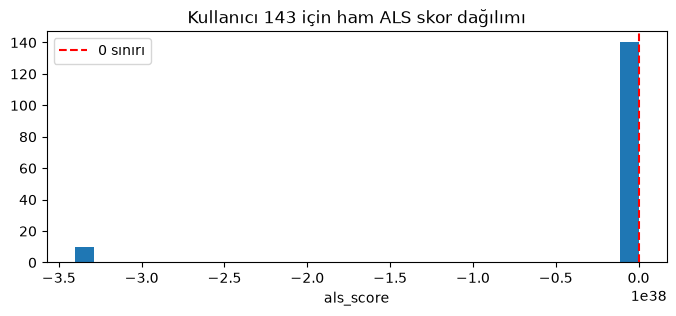

In [6]:
row_idx = user_index[sample_user_id]
ids, scores = model.recommend(
    userid=row_idx,
    user_items=user_items[row_idx],
    N=len(product_ids),
    filter_already_liked_items=True,
)

score_df = pd.DataFrame({"product_id": [product_ids[i] for i in ids], "als_score": scores})
print("En düşük 5 ham ALS skoru (negatif olabiliyor):")
display(score_df.tail(5))
print("En yüksek 5 ham ALS skoru:")
display(score_df.head(5))

plt.figure(figsize=(8, 3))
plt.hist(scores, bins=30)
plt.axvline(0, color="red", linestyle="--", label="0 sınırı")
plt.title(f"Kullanıcı {sample_user_id} için ham ALS skor dağılımı")
plt.xlabel("als_score")
plt.legend()
plt.show()

## 6. Hibrit skor: ALS + kategori affinity

`final_score = als_score + CATEGORY_AFFINITY_WEIGHT * kategori_payi`

Aşağıda aynı kullanıcı için, boost öncesi ve sonrası sıralamanın nasıl değiştiğini karşılaştırıyoruz.

In [7]:
affinity = category_affinity.get(sample_user_id, {})
score_df["category_id"] = score_df["product_id"].map(product_categories)
score_df["category_share"] = score_df["category_id"].map(lambda c: affinity.get(c, 0.0))
score_df["final_score"] = score_df["als_score"] + CATEGORY_AFFINITY_WEIGHT * score_df["category_share"]
score_df = score_df.merge(products_df[["id", "name"]], left_on="product_id", right_on="id")
score_df = score_df.merge(categories_df[["id", "slug"]], left_on="category_id", right_on="id", suffixes=("", "_cat"))

print("Sadece ham ALS skoruna göre ilk 10:")
display(score_df.sort_values("als_score", ascending=False)[["name", "slug", "als_score"]].head(10))

print("Hibrit skora göre ilk 10 (kategori boost'lu):")
display(score_df.sort_values("final_score", ascending=False)[["name", "slug", "final_score"]].head(10))

Sadece ham ALS skoruna göre ilk 10:


,name,slug,als_score
0,Basic Tişört,tisort,0.813188
1,Uzun Kollu Tişört,tisort,0.679167
2,Spor Ayakkabı,ayakkabi,0.660323
3,Kadife Pantolon,pantolon,0.650852
4,Basic Tişört,tisort,0.647564
5,Eldiven,canta-aksesuar,0.619732
6,Askılı Elbise,elbise,0.592639
7,Sneaker,ayakkabi,0.558311
8,Dekoratif Vazo,ev-yasam,0.533234
9,Pamuklu Tişört,tisort,0.482048


Hibrit skora göre ilk 10 (kategori boost'lu):


,name,slug,final_score
0,Basic Tişört,tisort,0.896521
27,Blazer Ceket,ceket-mont,0.853074
36,Şişme Mont,ceket-mont,0.801545
38,Bomber Ceket,ceket-mont,0.796334
40,Kapüşonlu Mont,ceket-mont,0.791083
41,Şişme Mont,ceket-mont,0.786944
1,Uzun Kollu Tişört,tisort,0.762500
52,Deri Ceket,ceket-mont,0.733674
4,Basic Tişört,tisort,0.730898
63,Bomber Ceket,ceket-mont,0.681293


## 7. Kalite kontrolü: personaya göre kategori isabet oranı

Her persona için, kullanıcıların ilk 3 önerisinde kendi ilgi kategorisinden en az bir ürün var mı? (Bunu `train.py` çalıştırdıktan sonra Laravel tinker ile de kontrol etmiştik — burada Python tarafında tekrar üretiyoruz.)

/var/folders/8x/2pmz1st135bf58p14psrdc7m0000gn/T/ipykernel_54395/2877750461.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  users_df = pd.read_sql("SELECT id, persona, store_id FROM users", conn)


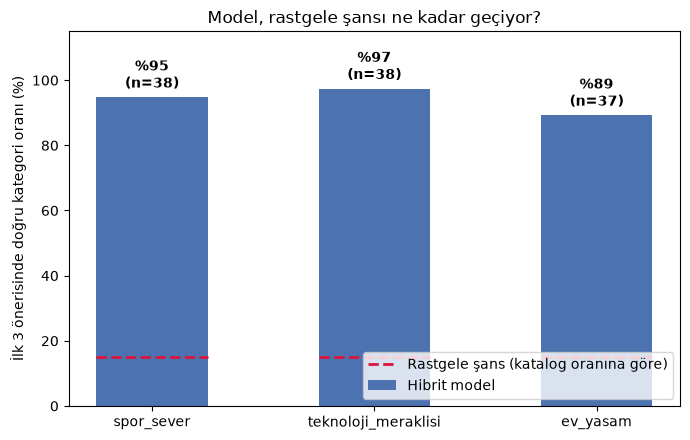

,model_orani_%,rastgele_sans_%,kullanici_sayisi
spor_sever,94.7,15.2,38
teknoloji_meraklisi,97.4,15.2,38
ev_yasam,89.2,15.2,37


In [8]:
users_df = pd.read_sql("SELECT id, persona, store_id FROM users", conn)
persona_category_map = {"spor_sever": "spor", "teknoloji_meraklisi": "teknoloji", "ev_yasam": "ev-yasam"}

category_product_counts = products_df["category_id"].value_counts()
total_products = len(products_df)

hit_rates = {}
baseline_rates = {}
sample_sizes = {}
for persona, target_slug in persona_category_map.items():
    target_category_id = categories_df.set_index("slug").loc[target_slug, "id"]
    persona_user_ids = users_df.loc[users_df["persona"] == persona, "id"]
    hits = 0
    total = 0
    for uid in persona_user_ids:
        if uid not in user_index:
            continue
        total += 1
        ridx = user_index[uid]
        ids_u, scores_u = model.recommend(userid=ridx, user_items=user_items[ridx], N=len(product_ids), filter_already_liked_items=True)
        aff = category_affinity.get(uid, {})
        cats = [product_categories[product_ids[i]] for i in ids_u]
        finals = [s + CATEGORY_AFFINITY_WEIGHT * aff.get(c, 0.0) for s, c in zip(scores_u, cats)]
        top3_idx = np.argsort(finals)[::-1][:3]
        top3_slugs = categories_df.set_index("id").loc[[cats[i] for i in top3_idx], "slug"].tolist()
        if target_slug in top3_slugs:
            hits += 1
    hit_rates[persona] = hits / total if total else 0
    sample_sizes[persona] = total

    # Kiyaslama: urunler tamamen rastgele onerilseydi, 3 secimden en az
    # birinin bu kategoriden gelme ihtimali ne olurdu? (katalogtaki gercek
    # kategori oranina gore hesaplaniyor)
    p_single = category_product_counts[target_category_id] / total_products
    baseline_rates[persona] = 1 - (1 - p_single) ** 3

personas = list(hit_rates.keys())
model_values = [hit_rates[p] * 100 for p in personas]
baseline_values = [baseline_rates[p] * 100 for p in personas]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(personas, model_values, color="#4C72B0", width=0.5, label="Hibrit model")

for bar, base, persona in zip(bars, baseline_values, personas):
    height = bar.get_height()
    n = sample_sizes[persona]
    ax.text(bar.get_x() + bar.get_width() / 2, height + 3, f"%{height:.0f}\n(n={n})", ha="center", fontsize=10, fontweight="bold")
    ax.plot([bar.get_x(), bar.get_x() + bar.get_width()], [base, base], color="crimson", linestyle="--", linewidth=2)

ax.plot([], [], color="crimson", linestyle="--", linewidth=2, label="Rastgele şans (katalog oranına göre)")
ax.set_ylim(0, 115)
ax.set_ylabel("İlk 3 önerisinde doğru kategori oranı (%)")
ax.set_title("Model, rastgele şansı ne kadar geçiyor?")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "model_orani_%": [round(v, 1) for v in model_values],
    "rastgele_sans_%": [round(v, 1) for v in baseline_values],
    "kullanici_sayisi": [sample_sizes[p] for p in personas],
}, index=personas)

## 8. Veritabanına yazmak istersen

Bu notebook keşif amaçlı olduğu için normalde veritabanına yazmıyor. Gerçekten `recommendations` tablosunu güncellemek istersen, terminalden `python train.py` çalıştırman yeterli — aynı mantığı otomatik uçtan uca yapıyor.

In [9]:
conn.close()